# Import Libraries

In [2]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt # plotting
import numpy as np
import os 
import pandas as pd 
import seaborn as sns

# Reading the Dataset

In [3]:
nRowsRead = None # specify 'None' if want to read whole file
# winequality-red.csv may have more rows in reality, but we are only loading/previewing the first 1000 rows
df1 = pd.read_csv('../../../dataset/winequality-red.csv', delimiter=',', nrows = nRowsRead)
df1.dataframeName = 'winequality-red.csv'
nRow, nCol = df1.shape
print(f'There are {nRow} rows and {nCol} columns')

There are 1599 rows and 12 columns


#  Exploratory Data Analysis

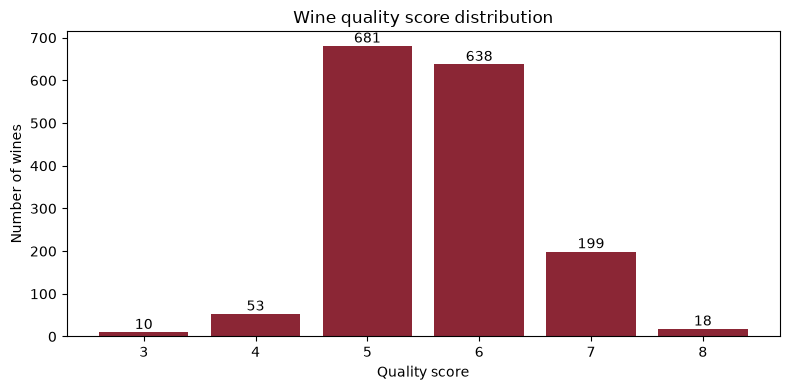

In [4]:
# Count wines at each observed quality score.
quality_counts = df1["quality"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(quality_counts.index.astype(str), quality_counts.values, color="#8b2635")
ax.set(title="Wine quality score distribution", xlabel="Quality score", ylabel="Number of wines")
for index, count in enumerate(quality_counts.values):
    ax.text(index, count, str(count), ha="center", va="bottom")
fig.tight_layout()
plt.show()

### Feature distributions
Inspect the range and skew of each input feature before interpreting the model.

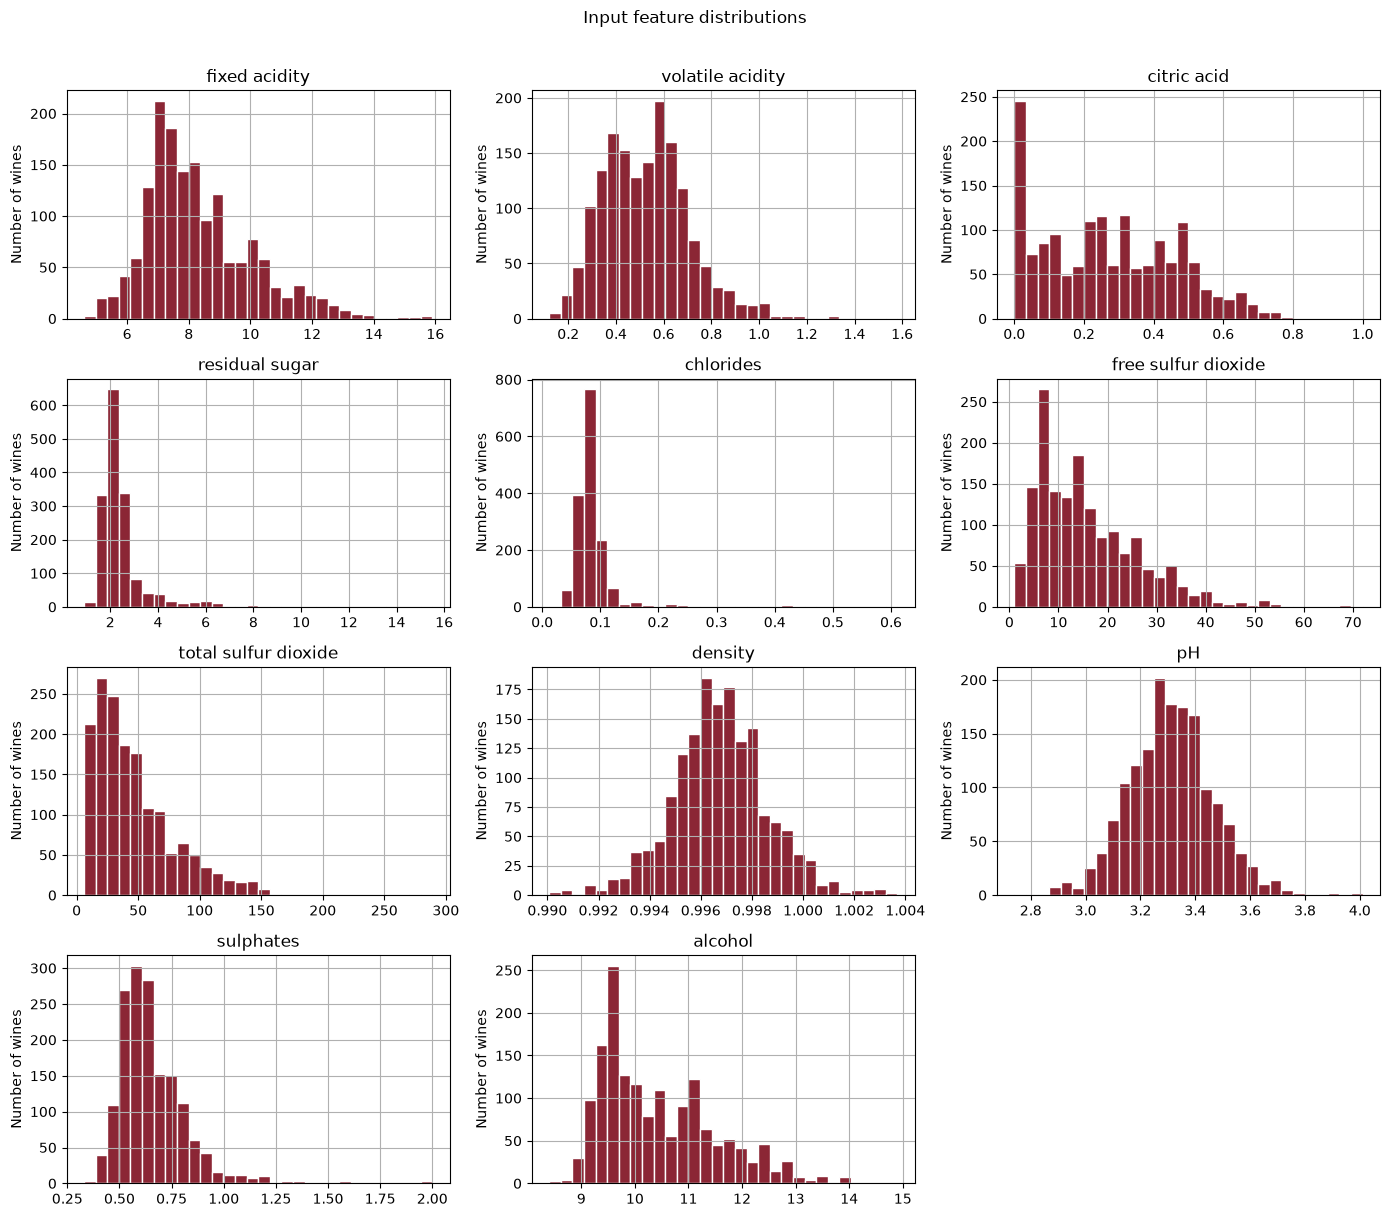

In [5]:
# Histograms show every model input without filtering by number of unique values.
feature_columns = df1.drop(columns="quality").select_dtypes(include=np.number).columns
axes = df1[feature_columns].hist(figsize=(14, 12), bins=30, color="#8b2635", edgecolor="white")
for ax in axes.flat:
    ax.set_ylabel("Number of wines")
plt.suptitle("Input feature distributions", y=1.01)
plt.tight_layout()
plt.show()

### Correlations
Correlations describe relationships in the data; they do not measure feature importance in a fitted model.

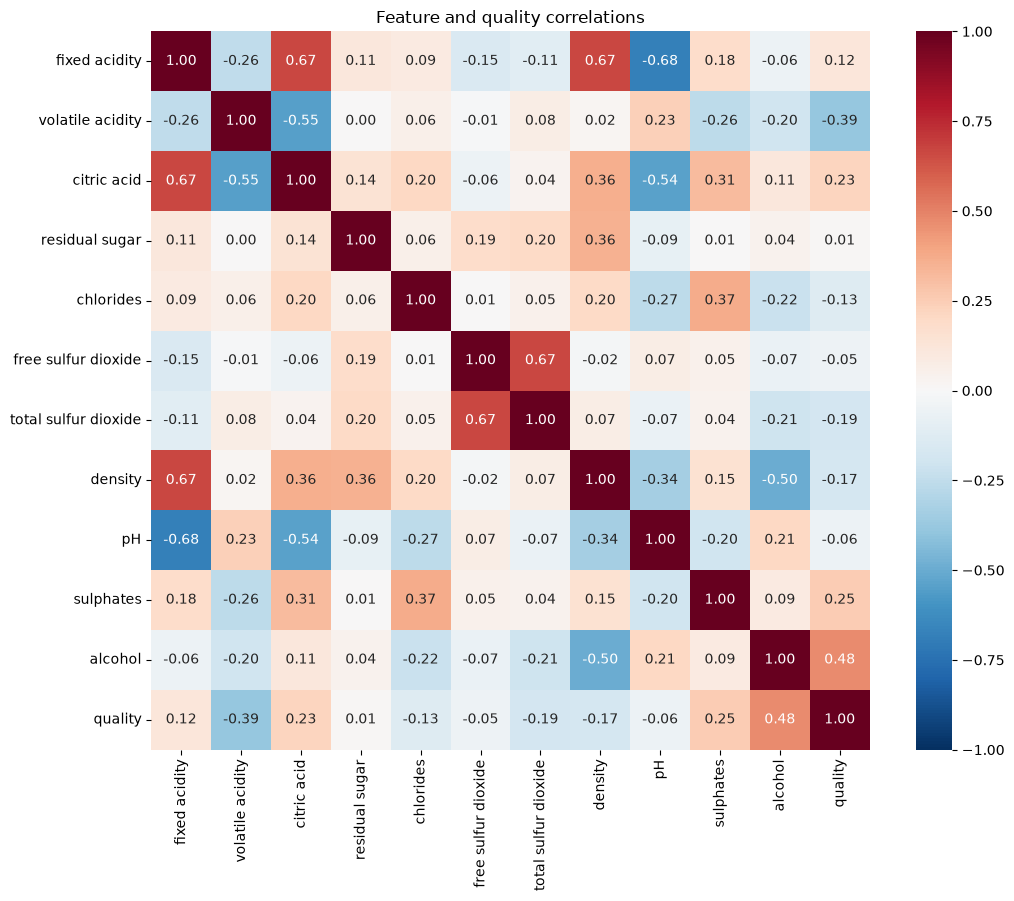

In [6]:
# Include quality to see which features have a linear association with the target.
correlations = df1[[*feature_columns, "quality"]].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(correlations, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Feature and quality correlations")
fig.tight_layout()
plt.show()

### Features across quality scores
Compare the distributions of the features most correlated with quality.

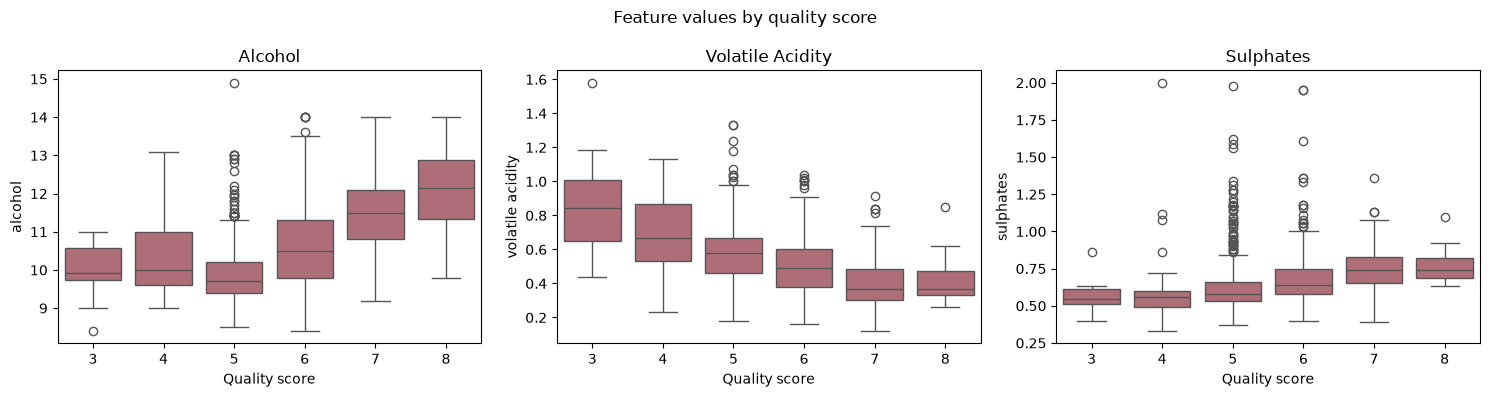

In [7]:
# Select three features from this dataset rather than assuming fixed rankings.
top_features = correlations["quality"].drop("quality").abs().nlargest(3).index
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feature in zip(axes, top_features):
    sns.boxplot(data=df1, x="quality", y=feature, color="#b86370", ax=ax)
    ax.set(xlabel="Quality score", ylabel=feature, title=feature.title())
fig.suptitle("Feature values by quality score")
fig.tight_layout()
plt.show()

### Relationship between two features
A scatter plot shows overlap between quality scores that one-feature summaries can hide.

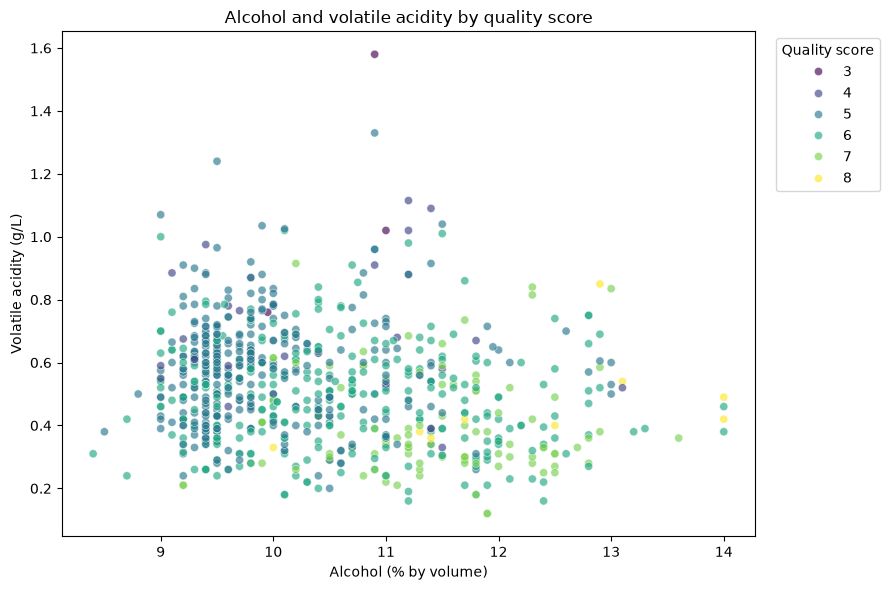

In [8]:
# A sample keeps the plot readable while preserving the score mix.
plot_data = df1.sample(n=min(800, len(df1)), random_state=42)
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=plot_data, x="alcohol", y="volatile acidity", hue="quality",
                palette="viridis", alpha=0.65, s=35, ax=ax)
ax.set(title="Alcohol and volatile acidity by quality score",
       xlabel="Alcohol (% by volume)", ylabel="Volatile acidity (g/L)")
ax.legend(title="Quality score", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

The plots above use raw quality scores. The training cells below transform the target with `log1p` and the export cell converts predictions back to quality points.

# Feature Engineering

In [9]:
# Extracting features and target variables
X=df1.iloc[:,:-1]
y=df1.iloc[:,-1].values
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [10]:
y=np.log1p(y)
print(y)

[1.79175947 1.79175947 1.79175947 ... 1.94591015 1.79175947 1.94591015]


In [11]:
# Splitting the dataset into training and test sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

# Model Training

In [ ]:
# Three permitted regression algorithms
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# Initializing the model
regressor_two=xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

In [ ]:
# Training the regressor
regressor_two.fit(X_train,y_train)

In [ ]:
# Initializing the architecture
regressor_three=lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    random_state=42
)

In [ ]:
# Training the model
regressor_three.fit(X_train,y_train)

In [ ]:
# Initializing the model
regressor_fourth=RandomForestRegressor(n_estimators=20,random_state=0)

In [ ]:
# Training the model
regressor_fourth.fit(X_train,y_train)

# Model Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
# Held-out predictions on the log1p target scale
x_pred = regressor_two.predict(X_test)
l_pred = regressor_three.predict(X_test)
r_pred = regressor_fourth.predict(X_test)

In [ ]:
# Mean absolute error in original quality-score points
actual_quality = np.expm1(y_test)
mae_x = mean_absolute_error(actual_quality, np.expm1(x_pred))
mae_l = mean_absolute_error(actual_quality, np.expm1(l_pred))
mae_r = mean_absolute_error(actual_quality, np.expm1(r_pred))

In [ ]:
# Compare the three permitted models
print(f"Mean Absolute Error of XGBoost: {mae_x:.3f} points")
print(f"Mean Absolute Error of LightGBM: {mae_l:.3f} points")
print(f"Mean Absolute Error of Random Forest: {mae_r:.3f} points")

# Export Values

In [ ]:
# Export fitted models, held-out diagnostics, and EDA data for Streamlit.
# Rerun this cell after changing any training or evaluation cell above.
from decimal import Decimal
import joblib
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error
from red_wine_quality_app.model import ARTIFACT_PATH, FEATURE_STEPS

quality_scores = tuple(range(3, 9))
assert tuple(X.columns) == tuple(FEATURE_STEPS), "The notebook feature order must match the app"
actual = np.rint(np.expm1(y_test)).astype(int)
features = []
for name, step in FEATURE_STEPS.items():
    decimals = max(0, -Decimal(str(step)).as_tuple().exponent)
    minimum = round(float(X[name].min()), decimals)
    maximum = round(float(X[name].max()), decimals)
    median = float(X[name].median())
    default = round(minimum + round((median - minimum) / step) * step, decimals)
    features.append(dict(name=name, minimum=minimum, maximum=maximum,
                         default=max(minimum, min(maximum, default)),
                         step=step, display_format=f"%.{decimals}f"))

models = {}
for name, estimator in {
    "Random Forest": regressor_fourth,
    "XGBoost": regressor_two,
    "LightGBM": regressor_three,
}.items():
    predicted = np.expm1(estimator.predict(X_test))
    rounded = np.clip(np.rint(predicted), quality_scores[0], quality_scores[-1]).astype(int)
    accuracy = float(accuracy_score(actual, rounded))
    matrix = confusion_matrix(actual, rounded, labels=quality_scores)
    report = classification_report(actual, rounded, labels=quality_scores,
                                   output_dict=True, zero_division=0)
    models[name] = {
        "estimator": estimator,
        "feature_importances": [float(value) for value in estimator.feature_importances_],
        "test_predictions": predicted.tolist(),
        "metrics": {
            "accuracy": accuracy,
            "error_rate": 1 - accuracy,
            "within_one_accuracy": float((np.abs(actual - rounded) <= 1).mean()),
            "mean_absolute_error": float(mean_absolute_error(actual, predicted)),
            "weighted_f1": float(report["weighted avg"]["f1-score"]),
            "classification_report": [
                {"Quality score": score, "Precision": report[str(score)]["precision"],
                 "Recall": report[str(score)]["recall"],
                 "F1-Score": report[str(score)]["f1-score"],
                 "Support": int(report[str(score)]["support"])}
                for score in quality_scores
            ],
            "quality_scores": quality_scores,
            "confusion_matrix": matrix.tolist(),
            "actual_counts": [int((actual == score).sum()) for score in quality_scores],
            "predicted_counts": [int((rounded == score).sum()) for score in quality_scores],
        },
    }

ARTIFACT_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump({"version": 2, "feature_names": tuple(X.columns), "features": features,
             "train_size": len(X_train), "test_size": len(X_test),
             "test_actual": actual.tolist(),
             "eda_data": df1[[*X.columns, "quality"]].to_dict(orient="list"),
             "models": models}, ARTIFACT_PATH, compress=3)
print(f"Exported {len(models)} models to {ARTIFACT_PATH}")